In [1]:
import pandas as pd

In [2]:
pip install -r ../requirements.txt --user

Note: you may need to restart the kernel to use updated packages.


In [3]:
df = pd.read_csv('../data/base_wine_limpa.csv')

In [4]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,cluster_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,0


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [17]:
# Separando features e target
X = df.drop(columns=['quality', 'cluster_quality'])
y = df['cluster_quality']

In [18]:
# Dividindo treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [19]:
# Treinando o Random Forest
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [20]:
# Avaliando o modelo
y_pred = modelo_rf.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       261
           1       0.75      0.40      0.52        45

    accuracy                           0.89       306
   macro avg       0.83      0.69      0.73       306
weighted avg       0.88      0.89      0.88       306

[[255   6]
 [ 27  18]]


In [21]:
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',  # compensa o desbalanceamento
    random_state=42
)

In [23]:
# Treinar com class_weight balanceado
modelo_rf_balanceado = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
modelo_rf_balanceado.fit(X_train, y_train)

# Avaliar
y_pred_bal = modelo_rf_balanceado.predict(X_test)
print(classification_report(y_test, y_pred_bal))
print(confusion_matrix(y_test, y_pred_bal))

              precision    recall  f1-score   support

           0       0.90      0.97      0.94       261
           1       0.71      0.38      0.49        45

    accuracy                           0.89       306
   macro avg       0.80      0.68      0.71       306
weighted avg       0.87      0.89      0.87       306

[[254   7]
 [ 28  17]]


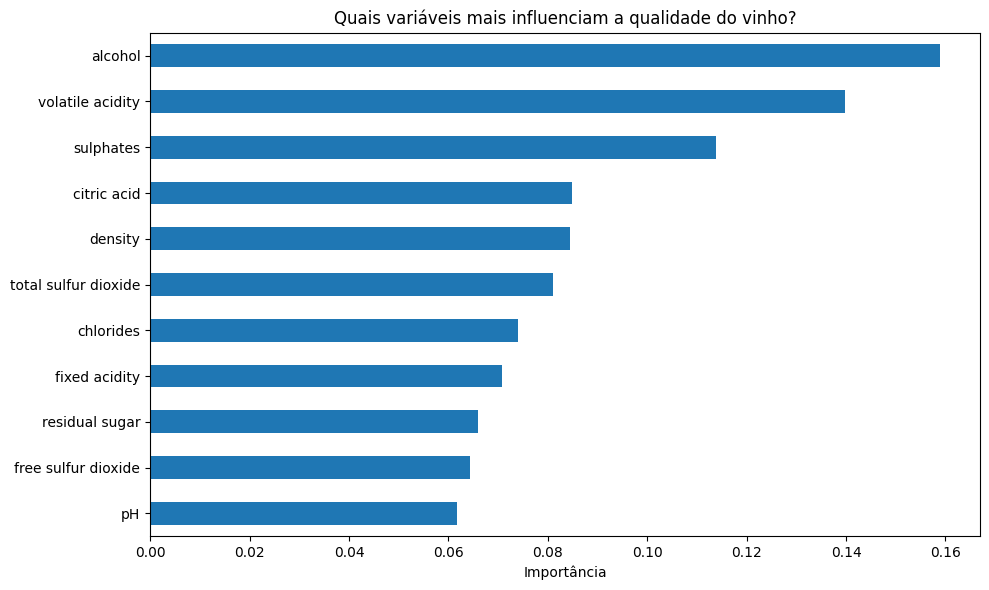

In [26]:
from sklearn.ensemble import RandomForestClassifier


# Treinar o modelo original (sem balanceamento - que foi o melhor)
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

# Extrair importâncias
importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

# Plotar
plt.figure(figsize=(10, 6))
importancias.plot(kind='barh')
plt.title('Quais variáveis mais influenciam a qualidade do vinho?')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()

In [32]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
# Baseline: sempre chuta classe majoritária (0 = baixa qualidade)
baseline_pred = np.zeros(len(y_test))

print("=== BASELINE (chuta sempre baixa qualidade) ===")
print(classification_report(y_test, baseline_pred, zero_division=0))
print(f"Acurácia: {accuracy_score(y_test, baseline_pred):.2f}")

print("\n=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred, zero_division=0))
print(f"Acurácia: {accuracy_score(y_test, y_pred):.2f}")


=== BASELINE (chuta sempre baixa qualidade) ===
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       261
           1       0.00      0.00      0.00        45

    accuracy                           0.85       306
   macro avg       0.43      0.50      0.46       306
weighted avg       0.73      0.85      0.79       306

Acurácia: 0.85

=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       261
           1       0.75      0.40      0.52        45

    accuracy                           0.89       306
   macro avg       0.83      0.69      0.73       306
weighted avg       0.88      0.89      0.88       306

Acurácia: 0.89
